### Лабораторная работа №2: Ядерные оценки плотности распределения.

Цели и задачи л/р: научиться строить ядерные оценки плотности распределения (KDE) и сравнить ее с гистограммой, оценить потери информации при построении оценок плотности распределения в сравнении с эмпирической функцией распределения, оценить статистическую точность оценок квантилей по оценкам плотности в сравнении с оценками квантили по эмпирической функции распределения.

1. Реализовать на любом языке программирования генерацию выборки из  

    а) нормального закона распределения с нулевым математическим ожиданием и единичной дисперсией,
    
    б) равномерного закона распределения на интервале от [0, 1].

In [1]:
import numpy as np

norm_sample = np.random.normal(loc=0.0, scale=1.0, size=10)
uni_sample = np.random.uniform(low=0.0, high=1.0, size=10)
print(*norm_sample)
print(*uni_sample)

0.25502972951725733 -0.828584586749403 -0.6641617996916412 -1.5851663667797768 1.6787602707973275 -1.1334469830541454 -1.6206640107849402 -0.545717407870499 0.8695302527094988 -0.09221995307081292
0.49840486952130936 0.11344500880216368 0.5944002187625194 0.4446171919016164 0.587444158870819 0.43505298123742164 0.01564497817048971 0.09974846892620093 0.0026654504349177266 0.07500232627785008


2. Реализовать построение ядерной оценки плотности с гауссовским ядром, а также
гистограммы для генерируемой автоматически выборки размером $n = 10^1, 10^2, 10^3, 10^4$ значений. При построении гистограммы. Количество полос k в гистограмме определять по соотношению $k \approx 1+1,59 * \ln(n)$, ширину полос выбирать одинаковой.

Для нормального распределения:

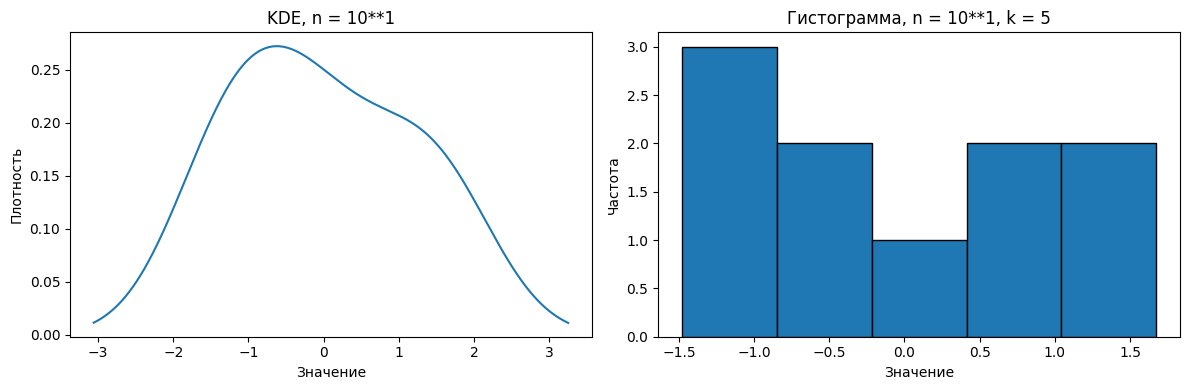

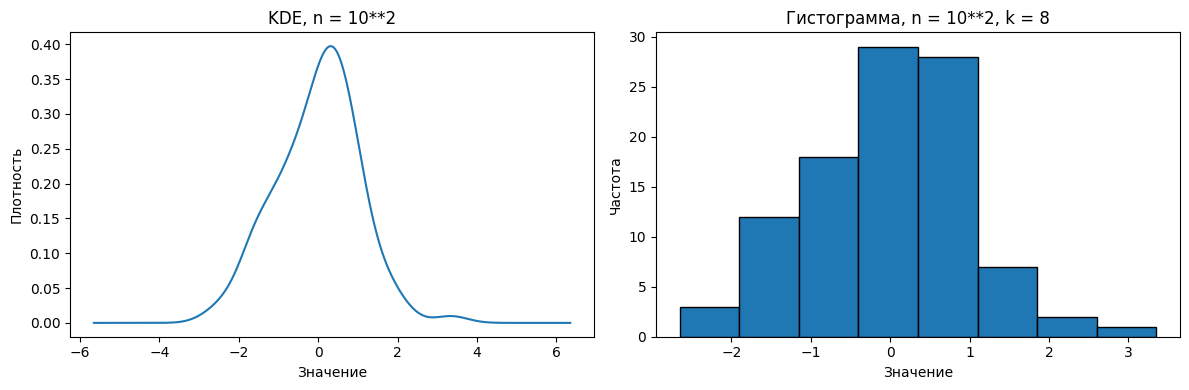

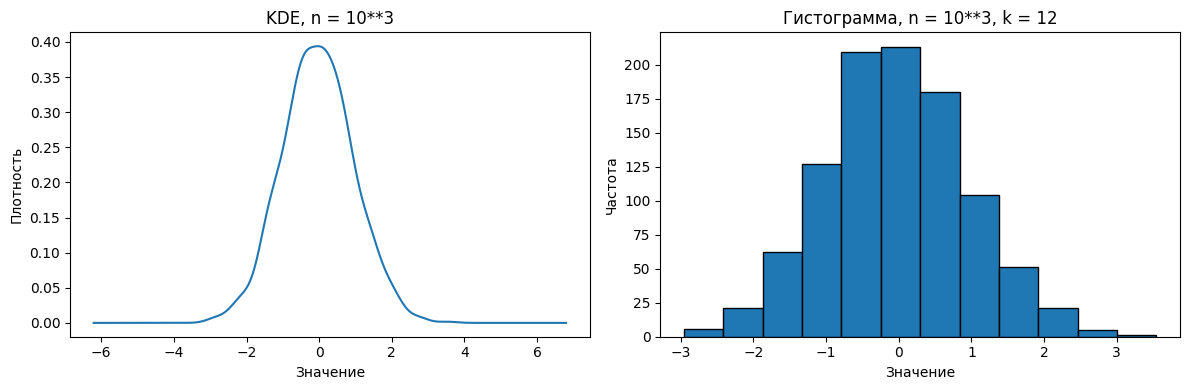

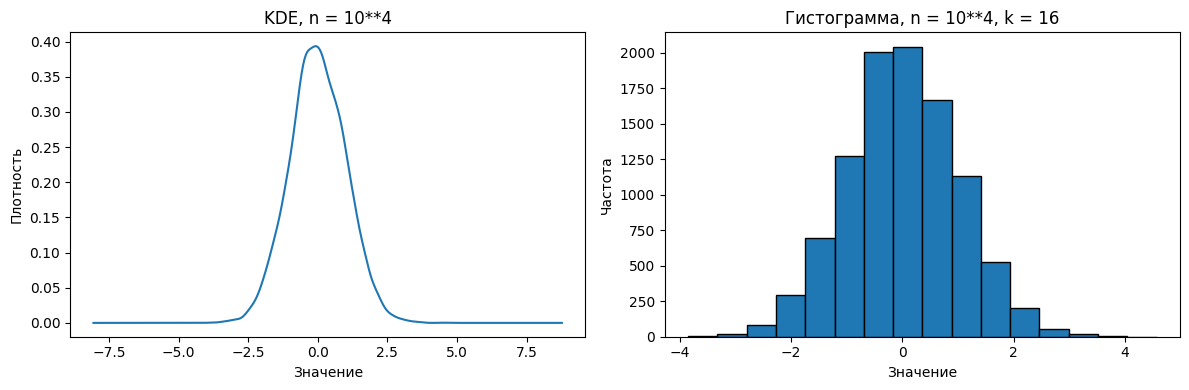

In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

for i in range(1, 5):
    n = 10**i
    sample = pd.Series(np.random.normal(loc=0.0, scale=1.0, size=n))

    k = int(round(1 + 1.59 * np.log(n)))
    bins = np.linspace(sample.min(), sample.max(), k + 1)

    fig, (ax_kde, ax_hist) = plt.subplots(1, 2, figsize=(12, 4))

    # KDE
    sample.plot.kde(ax=ax_kde)
    ax_kde.set_title(f"KDE, n = 10**{i}")
    ax_kde.set_xlabel("Значение")
    ax_kde.set_ylabel("Плотность")

    # гистограмма
    ax_hist.hist(sample, bins=bins, edgecolor='black')
    ax_hist.set_title(f"Гистограмма, n = 10**{i}, k = {k}")
    ax_hist.set_xlabel("Значение")
    ax_hist.set_ylabel("Частота")

    plt.tight_layout()
    plt.show()

Для равномерного распределения:

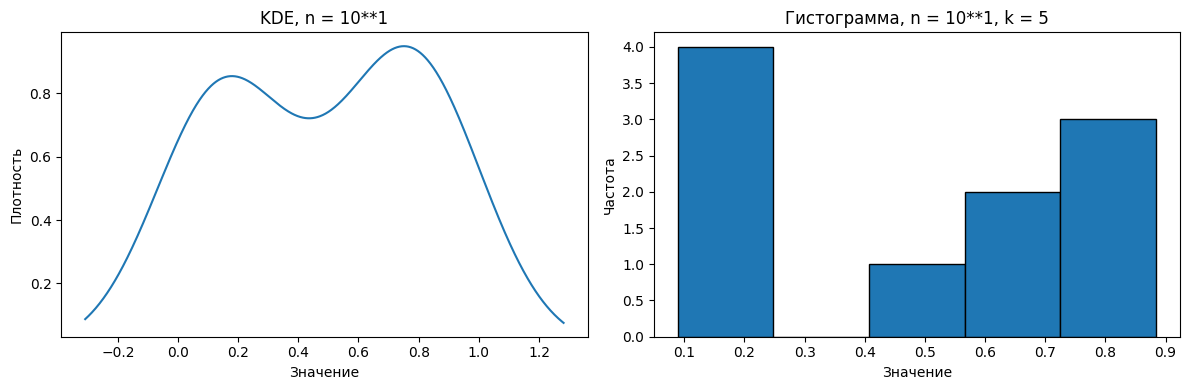

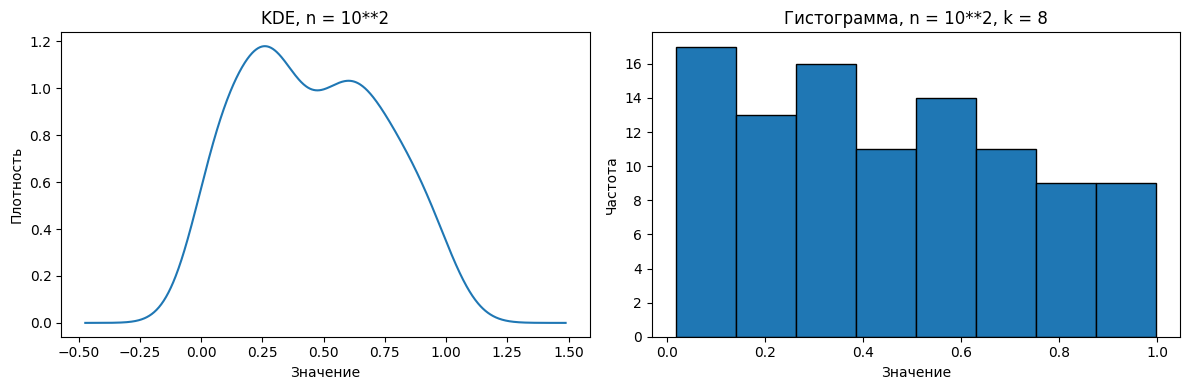

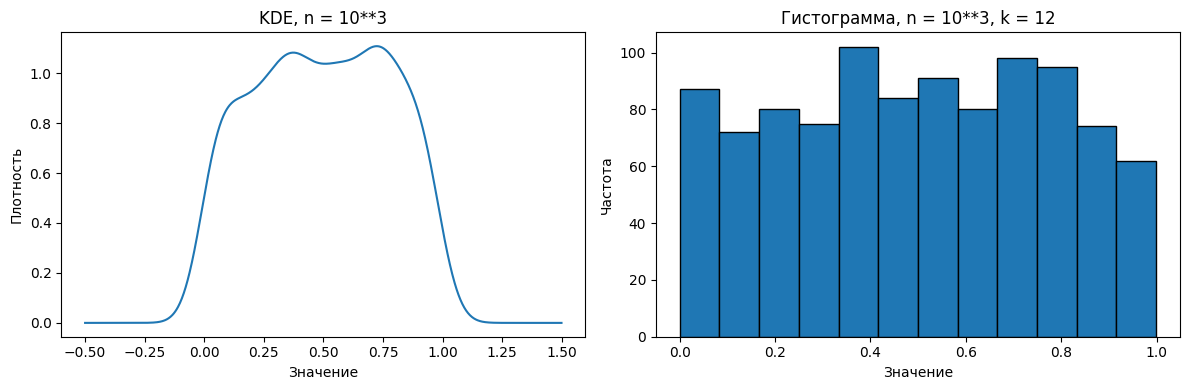

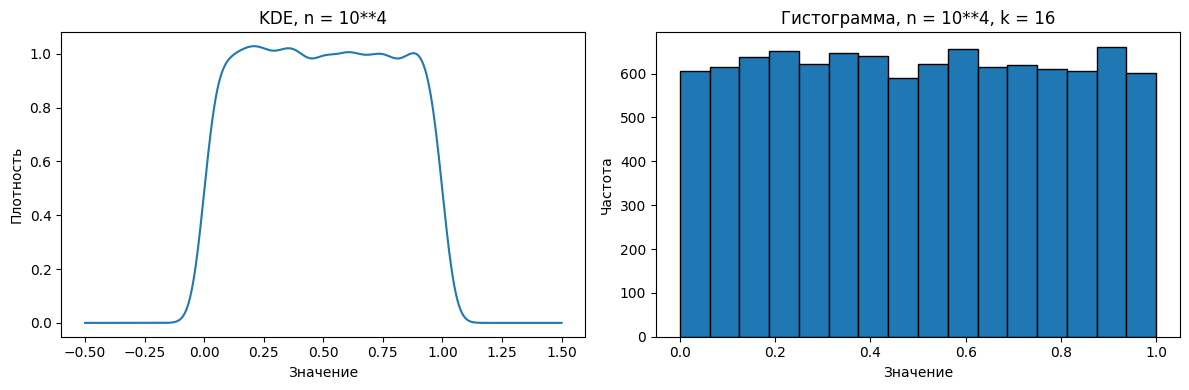

In [11]:
for i in range(1, 5):
    n = 10**i
    sample = pd.Series(np.random.uniform(low=0.0, high=1.0, size=n))

    k = int(round(1 + 1.59 * np.log(n)))
    bins = np.linspace(sample.min(), sample.max(), k + 1)

    fig, (ax_kde, ax_hist) = plt.subplots(1, 2, figsize=(12, 4))

    # KDE
    sample.plot.kde(ax=ax_kde)
    ax_kde.set_title(f"KDE, n = 10**{i}")
    ax_kde.set_xlabel("Значение")
    ax_kde.set_ylabel("Плотность")

    # гистограмма
    ax_hist.hist(sample, bins=bins, edgecolor='black')
    ax_hist.set_title(f"Гистограмма, n = 10**{i}, k = {k}")
    ax_hist.set_xlabel("Значение")
    ax_hist.set_ylabel("Частота")

    plt.tight_layout()
    plt.show()

3. Построить по каждой выборке оценки 1%, 5% и 50% квантилей тремя способами: по
выборочной функции распределения, по гистограмме и по ядерной оценке плотности.

Для нормального распределения:

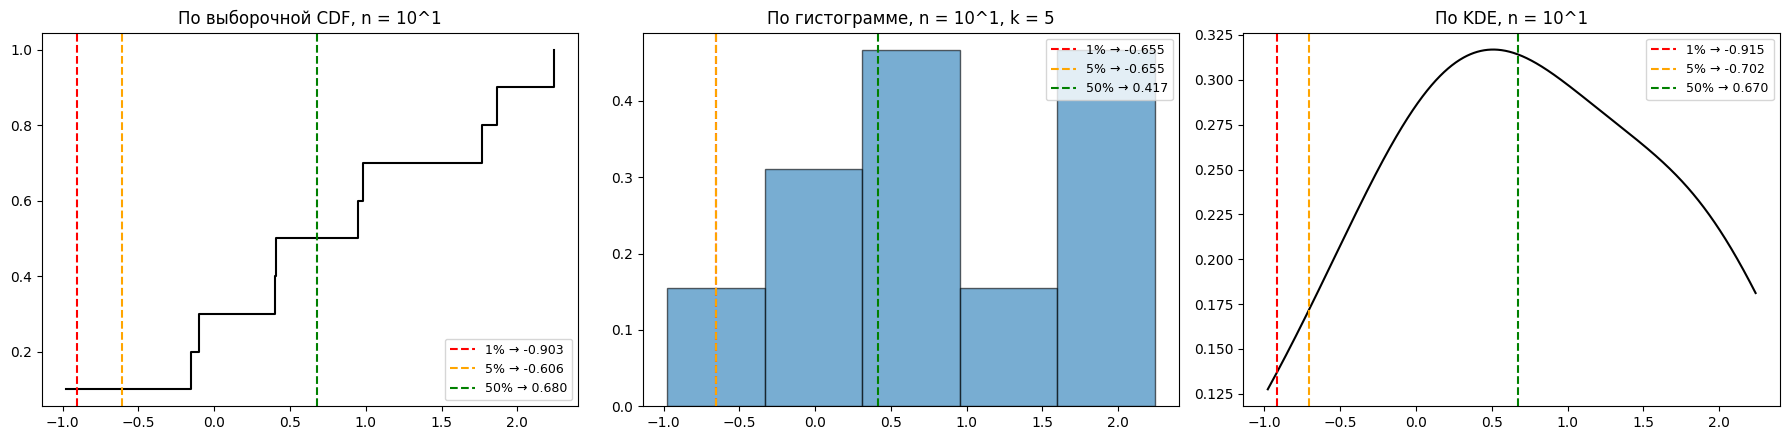

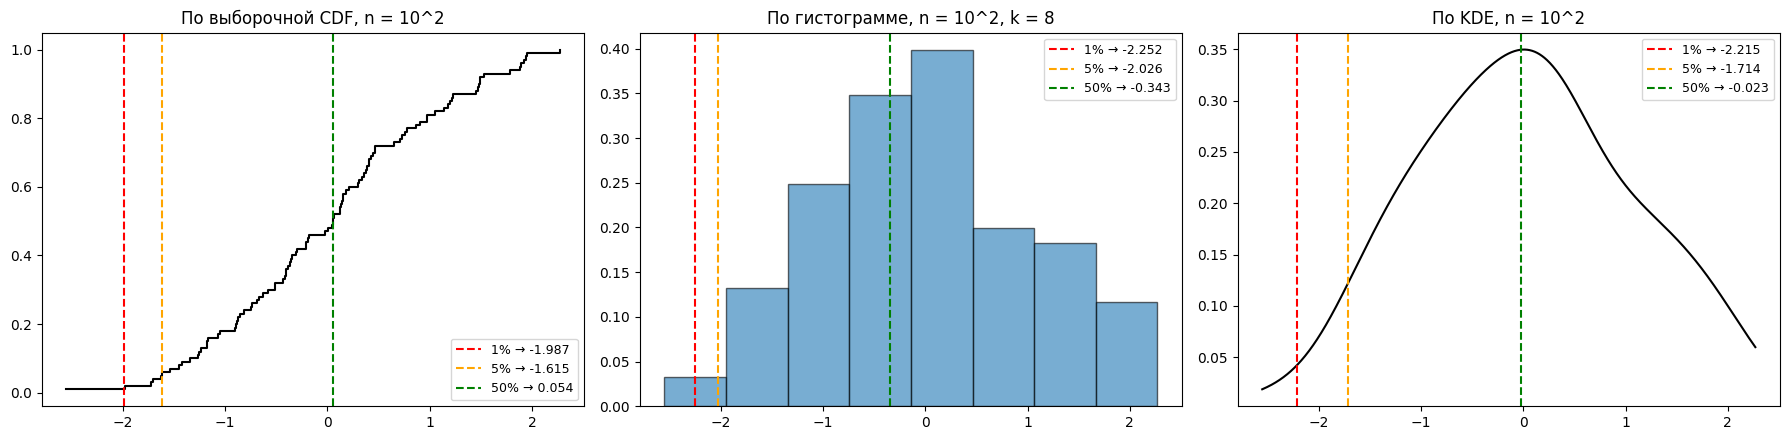

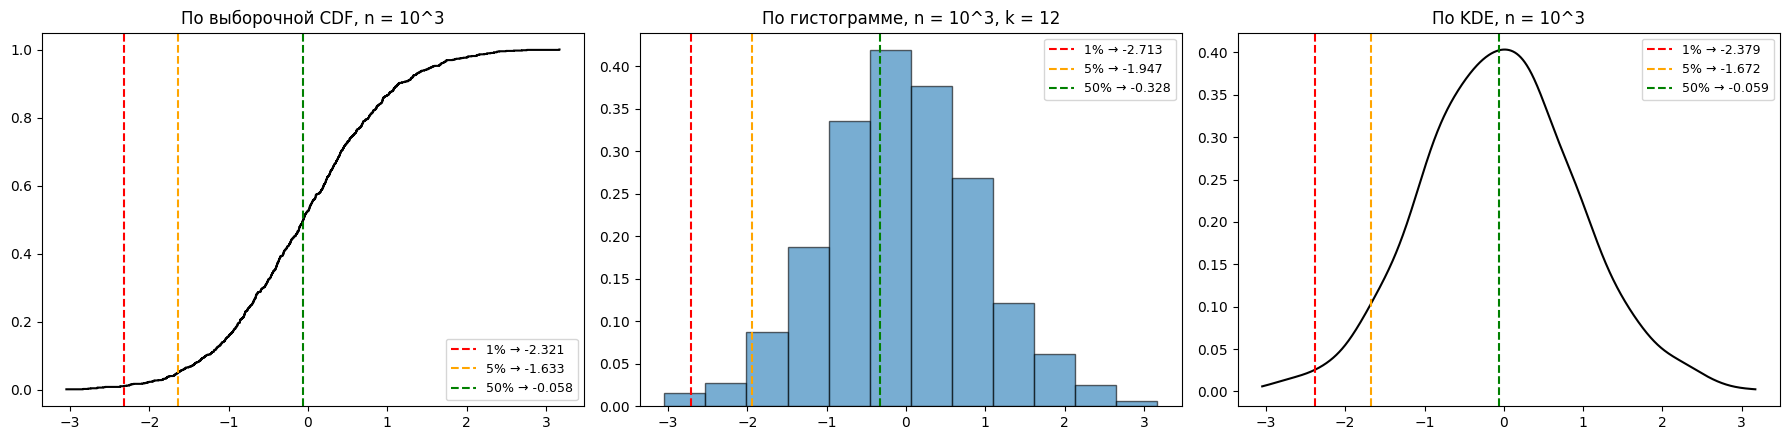

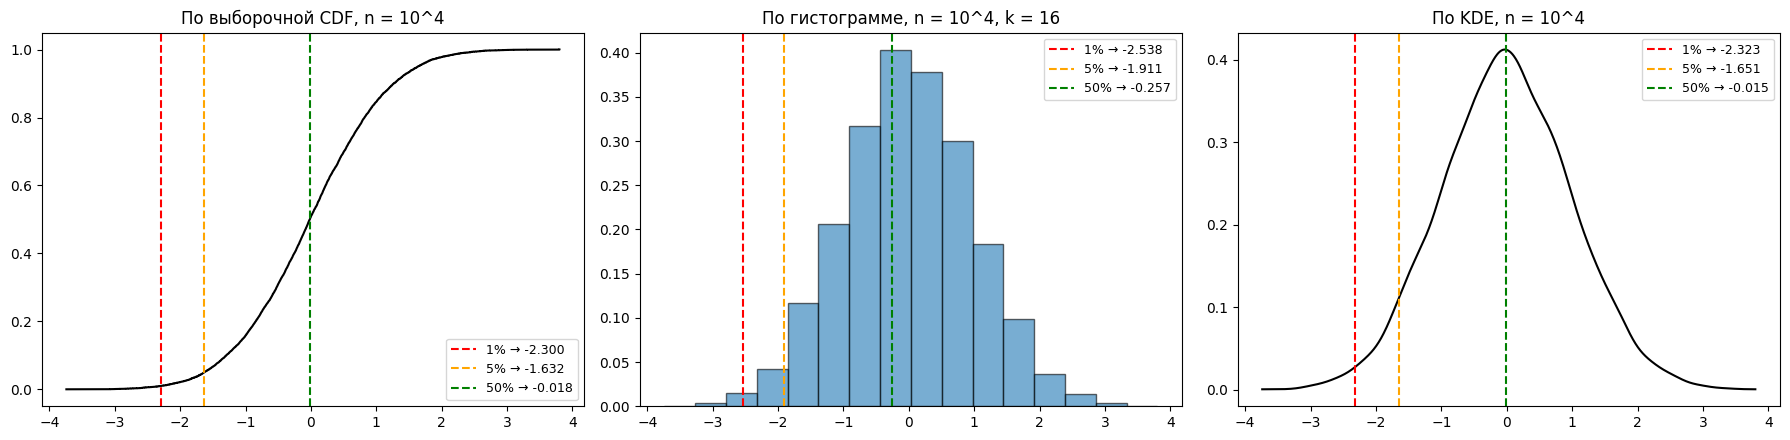

In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import cumulative_trapezoid
from scipy.stats import gaussian_kde

np.random.seed(0)

probs = [0.01, 0.05, 0.50]
colors = {0.01: 'red', 0.05: 'orange', 0.50: 'green'}


def quantiles_from_ecdf(sample, probs):
    return {p: float(np.quantile(sample, p)) for p in probs}


def quantiles_from_hist(sample, probs, bins):
    counts, edges = np.histogram(sample, bins=bins)
    cum = np.cumsum(counts) / counts.sum()
    centers = 0.5 * (edges[:-1] + edges[1:])
    return {p: float(np.interp(p, cum, centers)) for p in probs}, counts, edges


def quantiles_from_kde(sample, probs, grid_size=1000):
    kde = gaussian_kde(sample)
    x = np.linspace(sample.min(), sample.max(), grid_size)
    dens = kde(x)
    cdf = cumulative_trapezoid(dens, x, initial=0)
    cdf /= cdf[-1]
    return {p: float(np.interp(p, cdf, x)) for p in probs}, x, dens


for i in range(1, 5):
    n = 10**i
    sample = pd.Series(np.random.normal(loc=0.0, scale=1.0, size=n))

    k = int(round(1 + 1.59 * np.log(n)))
    bins = np.linspace(sample.min(), sample.max(), k + 1)

    q_ecdf = quantiles_from_ecdf(sample, probs)
    q_hist, counts, edges = quantiles_from_hist(sample, probs, bins)
    q_kde, x_grid, dens = quantiles_from_kde(sample, probs)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    ax_cdf, ax_hist, ax_kde = axes

    # 1) эмпирическая CDF
    xs = np.sort(sample.values)
    ys = np.arange(1, n + 1) / n
    ax_cdf.step(xs, ys, where='post', color='black')
    for p in probs:
        ax_cdf.axvline(q_ecdf[p], color=colors[p], ls='--', lw=1.5,
                       label=f"{int(p*100)}% → {q_ecdf[p]:.3f}")
    ax_cdf.set_title(f"По выборочной CDF, n = 10^{i}")
    ax_cdf.legend(fontsize=9)

    # 2) гистограмма
    ax_hist.hist(sample, bins=bins, density=True, edgecolor='black', alpha=0.6)
    for p in probs:
        ax_hist.axvline(q_hist[p], color=colors[p], ls='--', lw=1.5,
                        label=f"{int(p*100)}% → {q_hist[p]:.3f}")
    ax_hist.set_title(f"По гистограмме, n = 10^{i}, k = {k}")
    ax_hist.legend(fontsize=9)

    # 3) KDE
    ax_kde.plot(x_grid, dens, color='black')
    for p in probs:
        ax_kde.axvline(q_kde[p], color=colors[p], ls='--', lw=1.5,
                       label=f"{int(p*100)}% → {q_kde[p]:.3f}")
    ax_kde.set_title(f"По KDE, n = 10^{i}")
    ax_kde.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

Для равномерного распределения:

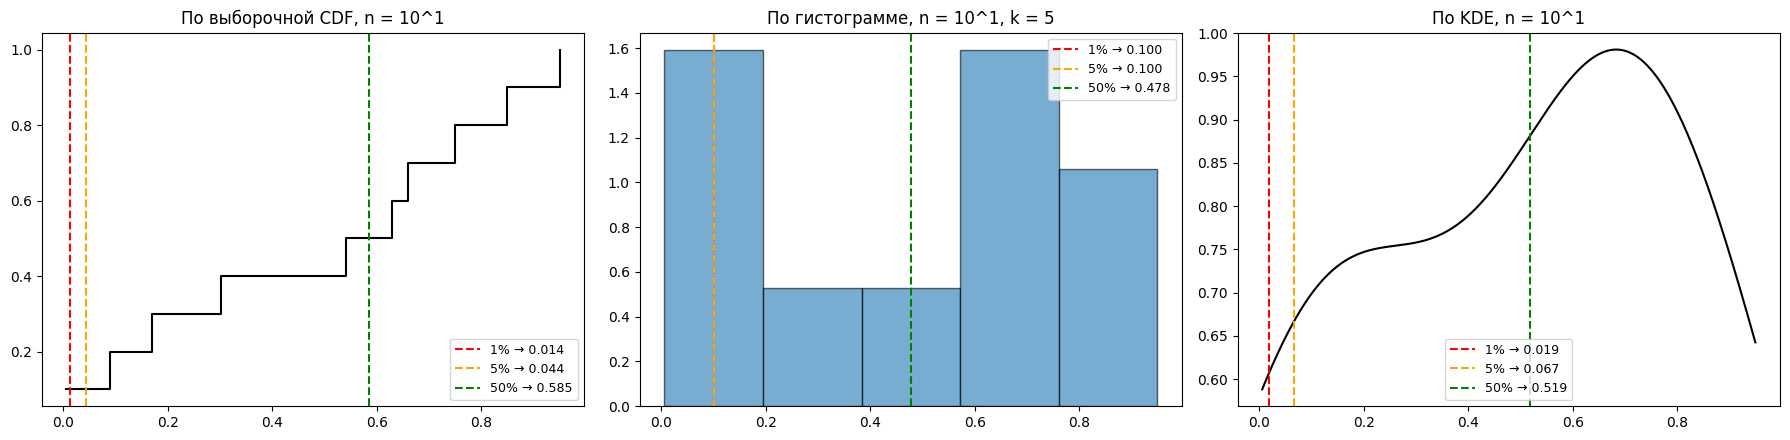

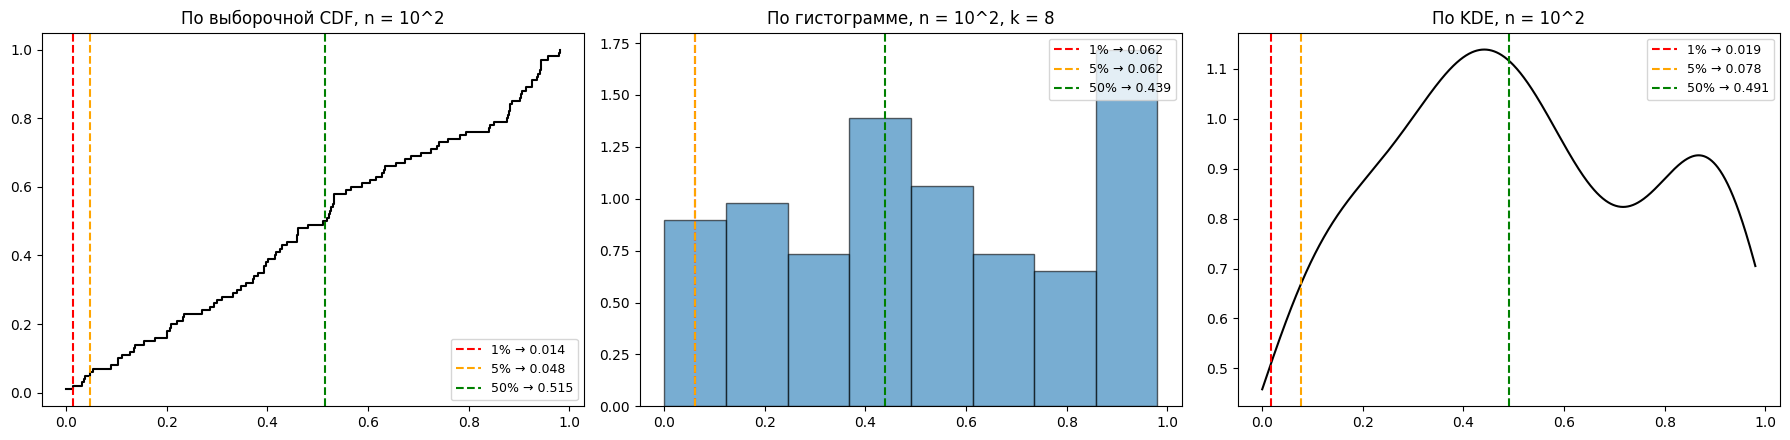

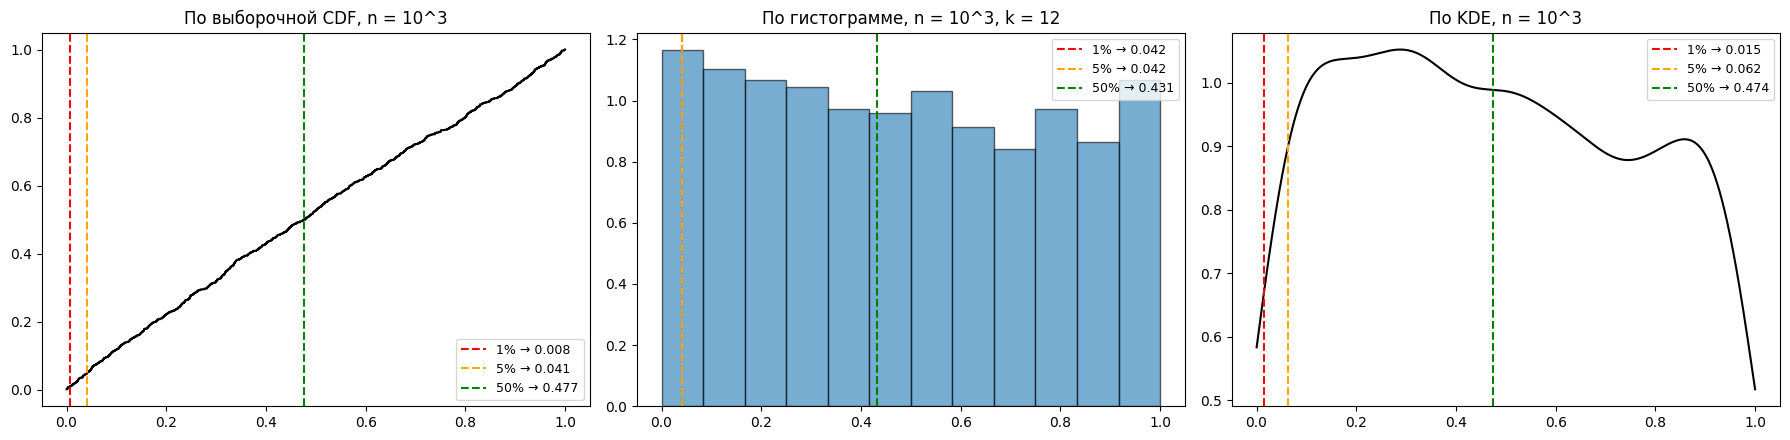

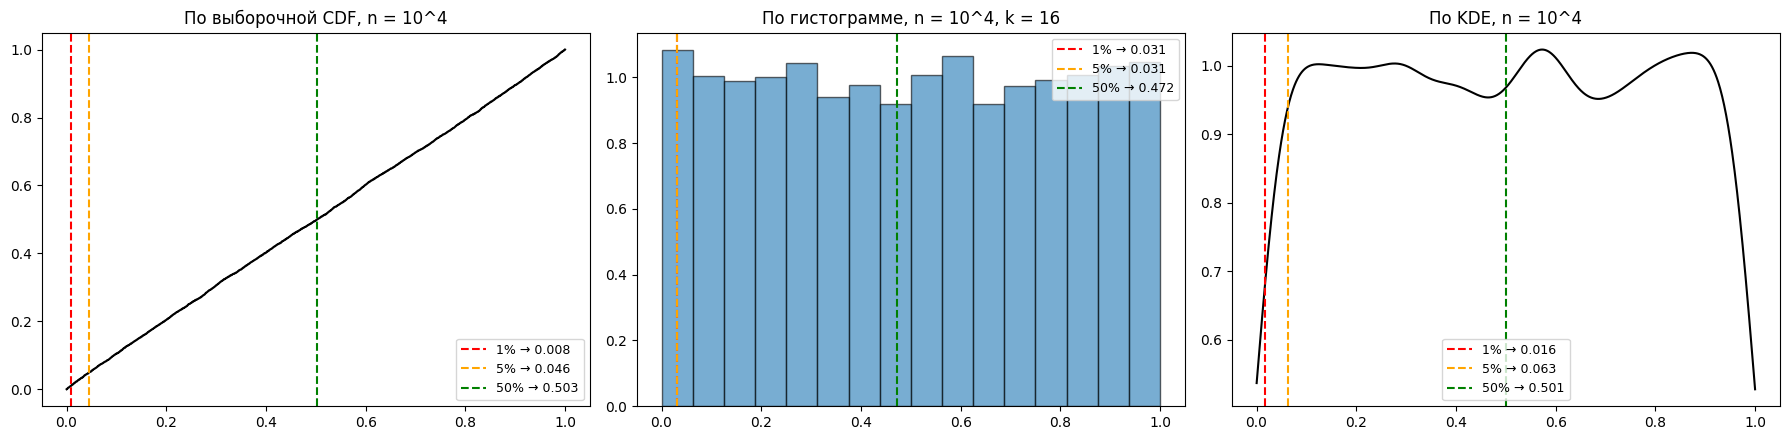

In [20]:
for i in range(1, 5):
    n = 10**i
    sample = pd.Series(np.random.uniform(low=0.0, high=1.0, size=n))

    k = int(round(1 + 1.59 * np.log(n)))
    bins = np.linspace(sample.min(), sample.max(), k + 1)

    q_ecdf = quantiles_from_ecdf(sample, probs)
    q_hist, counts, edges = quantiles_from_hist(sample, probs, bins)
    q_kde, x_grid, dens = quantiles_from_kde(sample, probs)

    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    ax_cdf, ax_hist, ax_kde = axes

    # 1) эмпирическая CDF
    xs = np.sort(sample.values)
    ys = np.arange(1, n + 1) / n
    ax_cdf.step(xs, ys, where='post', color='black')
    for p in probs:
        ax_cdf.axvline(q_ecdf[p], color=colors[p], ls='--', lw=1.5,
                       label=f"{int(p*100)}% → {q_ecdf[p]:.3f}")
    ax_cdf.set_title(f"По выборочной CDF, n = 10^{i}")
    ax_cdf.legend(fontsize=9)

    # 2) гистограмма
    ax_hist.hist(sample, bins=bins, density=True, edgecolor='black', alpha=0.6)
    for p in probs:
        ax_hist.axvline(q_hist[p], color=colors[p], ls='--', lw=1.5,
                        label=f"{int(p*100)}% → {q_hist[p]:.3f}")
    ax_hist.set_title(f"По гистограмме, n = 10^{i}, k = {k}")
    ax_hist.legend(fontsize=9)

    # 3) KDE
    ax_kde.plot(x_grid, dens, color='black')
    for p in probs:
        ax_kde.axvline(q_kde[p], color=colors[p], ls='--', lw=1.5,
                       label=f"{int(p*100)}% → {q_kde[p]:.3f}")
    ax_kde.set_title(f"По KDE, n = 10^{i}")
    ax_kde.legend(fontsize=9)

    plt.tight_layout()
    plt.show()

4. Повторить пункты 2 и 3 не менее $N = 10^3$ раз для каждого значения n и каждого распределения и по полученным N оценкам каждой квантили оценить значение ее дисперсии. Сделать выводы о информативности оценок квантилей по выборочной функции распределения, гистограмме и ядерной оценке плотности.

Для нормального распределения:

In [23]:
N = 10**3
n_values = [10**1, 10**2, 10**3, 10**4]

for n in n_values:
    k = int(round(1 + 1.59 * np.log(n)))

    # накопители: est[method][p] = список из N оценок
    est = {
        'ecdf': {p: [] for p in probs},
        'hist': {p: [] for p in probs},
        'kde':  {p: [] for p in probs},
    }

    for _ in range(N):
        sample = np.random.normal(loc=0.0, scale=1.0, size=n)
        bins = np.linspace(sample.min(), sample.max(), k + 1)

        q1 = quantiles_from_ecdf(sample, probs)
        q2, _, _ = quantiles_from_hist(sample, probs, bins)   # игнорируем counts, edges
        q3, _, _ = quantiles_from_kde(sample, probs)          # игнорируем x, dens

        for p in probs:
            est['ecdf'][p].append(q1[p])
            est['hist'][p].append(q2[p])
            est['kde'][p].append(q3[p])

    # ---------- таблица дисперсий ----------
    table = pd.DataFrame(
        index=[f"{int(p*100)}%" for p in probs],
        columns=['по CDF', 'по гистограмме', 'по KDE'],
        dtype=float,
    )
    for p in probs:
        table.loc[f"{int(p*100)}%", 'по CDF']         = np.var(est['ecdf'][p], ddof=1)
        table.loc[f"{int(p*100)}%", 'по гистограмме'] = np.var(est['hist'][p], ddof=1)
        table.loc[f"{int(p*100)}%", 'по KDE']         = np.var(est['kde'][p],  ddof=1)

    print(f"\n===== n = {n}  (k = {k}, N = {N}) =====")
    print("Дисперсия оценок квантилей:")
    print(table.round(6))


===== n = 10  (k = 5, N = 1000) =====
Дисперсия оценок квантилей:
       по CDF  по гистограмме    по KDE
1%   0.302941        0.280663  0.306823
5%   0.227326        0.280663  0.233461
50%  0.129037        0.134490  0.105337

===== n = 100  (k = 8, N = 1000) =====
Дисперсия оценок квантилей:
       по CDF  по гистограмме    по KDE
1%   0.092723        0.142226  0.073757
5%   0.042734        0.052615  0.031166
50%  0.015317        0.015870  0.012108

===== n = 1000  (k = 12, N = 1000) =====
Дисперсия оценок квантилей:
       по CDF  по гистограмме    по KDE
1%   0.014630        0.016371  0.009974
5%   0.004113        0.004710  0.003316
50%  0.001542        0.001784  0.001274

===== n = 10000  (k = 16, N = 1000) =====
Дисперсия оценок квантилей:
       по CDF  по гистограмме    по KDE
1%   0.001336        0.001942  0.001046
5%   0.000467        0.000905  0.000399
50%  0.000141        0.000312  0.000121


Для равномерного распределения:

In [24]:
for n in n_values:
    k = int(round(1 + 1.59 * np.log(n)))

    # накопители: est[method][p] = список из N оценок
    est = {
        'ecdf': {p: [] for p in probs},
        'hist': {p: [] for p in probs},
        'kde':  {p: [] for p in probs},
    }

    for _ in range(N):
        sample = np.random.uniform(low=0.0, high=1.0, size=n)
        bins = np.linspace(sample.min(), sample.max(), k + 1)

        q1 = quantiles_from_ecdf(sample, probs)
        q2, _, _ = quantiles_from_hist(sample, probs, bins)   # игнорируем counts, edges
        q3, _, _ = quantiles_from_kde(sample, probs)          # игнорируем x, dens

        for p in probs:
            est['ecdf'][p].append(q1[p])
            est['hist'][p].append(q2[p])
            est['kde'][p].append(q3[p])

    # ---------- таблица дисперсий ----------
    table = pd.DataFrame(
        index=[f"{int(p*100)}%" for p in probs],
        columns=['по CDF', 'по гистограмме', 'по KDE'],
        dtype=float,
    )
    for p in probs:
        table.loc[f"{int(p*100)}%", 'по CDF']         = np.var(est['ecdf'][p], ddof=1)
        table.loc[f"{int(p*100)}%", 'по гистограмме'] = np.var(est['hist'][p], ddof=1)
        table.loc[f"{int(p*100)}%", 'по KDE']         = np.var(est['kde'][p],  ddof=1)

    print(f"\n===== n = {n}  (k = {k}, N = {N}) =====")
    print("Дисперсия оценок квантилей:")
    print(table.round(6))


===== n = 10  (k = 5, N = 1000) =====
Дисперсия оценок квантилей:
       по CDF  по гистограмме    по KDE
1%   0.006696        0.005653  0.006616
5%   0.007494        0.005653  0.006419
50%  0.018978        0.019067  0.008968

===== n = 100  (k = 8, N = 1000) =====
Дисперсия оценок квантилей:
       по CDF  по гистограмме    по KDE
1%   0.000165        0.000079  0.000097
5%   0.000501        0.000079  0.000210
50%  0.002492        0.002333  0.001501

===== n = 1000  (k = 12, N = 1000) =====
Дисперсия оценок квантилей:
       по CDF  по гистограмме    по KDE
1%   0.000011        0.000001  0.000003
5%   0.000051        0.000001  0.000019
50%  0.000249        0.000232  0.000181

===== n = 10000  (k = 16, N = 1000) =====
Дисперсия оценок квантилей:
       по CDF  по гистограмме    по KDE
1%   0.000001        0.000000  0.000000
5%   0.000005        0.000000  0.000002
50%  0.000025        0.000024  0.000020
